# Recalage d'homographie a-contrario avec ORSA

**Theorie de la détection** - MVA, ENS Paris-Saclay, 2025-2026  
**Encadrants :** Rafael Grompone von Gioi, Quentin Bammey  
**Auteur :** Mouhssine Rifaki


## Resume

Etant donnees deux images d'une même scene liees par une transformation projective (homographie), le problème du recalage automatique necessite :
1. La recherche de **correspondances putatives** (appariement de primitives).
2. L'estimation robuste de l'homographie à partir de ces correspondances, dont la plupart peuvent être des **aberrants**.

RANSAC (Fischler & Bolles, 1981) est l'approche classique, mais depend d'un seuil d'inlier arbitraire $\varepsilon$. Le cadre **a-contrario** (Desolneux, Moisan & Morel, 2008) offre une alternative : un modèle est *significatif* s'il a une très faible probabilite de survenir par hasard. Le **Nombre de Fausses Alarmes (NFA)** quantifie cela, et l'algorithme **ORSA** (Moisan, Moulon & Monasse, 2012) minimise le NFA sur le modèle et le seuil, fournissant une méthode d'estimation robuste **sans paramètre**.

Ce notebook implémente et etudie :
1. L'estimateur d'homographie DLT avec normalisation de Hartley.
2. Le critère NFA a-contrario.
3. La comparaison ORSA vs. RANSAC sur des donnees synthetiques et réelles.
4. L'analyse de sensibilité d'ORSA a la contamination par des aberrants.
5. L'analyse de la distribution du NFA sous l'hypothese nulle.

## 1. Cadre mathematique

### 1.1 Modele d'homographie

Une **homographie** est une matrice $3\times 3$ inversible $\mathbf{H}$ (a un facteur d'echelle près) projetant les points de l'image 1 vers l'image 2 :

$$\tilde{\mathbf{x}}' = \mathbf{H} \tilde{\mathbf{x}}, \qquad \tilde{\mathbf{x}} = \begin{pmatrix} x \\ y \\ 1 \end{pmatrix},$$

ou $\tilde{\mathbf{x}}$ et $\tilde{\mathbf{x}}'$ sont des coordonnees homogènes. Elle possede 8 degres de liberte (9 coefficients moins le facteur d'echelle), donc un minimum de **4 correspondances de points** est nécessaire.

### 1.2 Transformation lineaire directe (DLT)

A partir de $n \geq 4$ correspondances $(\mathbf{x}_i, \mathbf{x}_i')$, la DLT construit une matrice $2n \times 9$ $\mathbf{A}$ telle que $\mathbf{A}\mathbf{h} = \mathbf{0}$, ou $\mathbf{h}$ est la vectorisation de $\mathbf{H}$. La solution est le vecteur singulier droit de $\mathbf{A}$ associe a la plus petite valeur singuliere.

**Normalisation de Hartley** (Hartley & Zisserman, 2003, Ch. 4) : les points sont preconditionnes de sorte que leur centroide soit a l'origine et que la distance moyenne a l'origine soit $\sqrt{2}$. Cela amélioré significativement la stabilité numérique.

### 1.3 Erreur de transfert symétrique

L'**erreur de transfert symétrique** pour une correspondance $(\mathbf{x}_i, \mathbf{x}_i')$ et une homographie $\mathbf{H}$ est :

$$e_i = d(\mathbf{x}_i', \mathbf{H}\mathbf{x}_i)^2 + d(\mathbf{x}_i, \mathbf{H}^{-1}\mathbf{x}_i')^2,$$

ou $d$ est la distance euclidienne entre coordonnees inhomogenes.

### 1.4 Le cadre a-contrario

**Principe de Helmholtz** (Desolneux et al., 2008) : une structure dans les donnees est *perceptuellement significative* si elle a une très faible probabilite de survenir par hasard dans un modèle de bruit $\mathcal{H}_0$.

**Modele de fond $\mathcal{H}_0$ :** Sous l'hypothese nulle (pas de vraie homographie), les correspondances sont supposees uniformement et indépendamment distribuees dans le domaine image.

**Nombre de Fausses Alarmes (NFA) :** Pour un modèle estime à partir de donnees avec $n$ correspondances, dont $k$ sont des inliers a un niveau de précision $\alpha$ (ou $\alpha = \pi r^2 / |\Omega|$ est la probabilite qu'un point aléatoire tombe a une distance $r$ du point projete) :

$$\operatorname{NFA}(k, \alpha) = N_{\text{tests}} \cdot \binom{n}{k} \cdot \alpha^{k-p},$$

ou $p = 4$ est la taille minimale de l'echantillon et $N_{\text{tests}} = n$ (tenant compte du nombre de seuils testes). En echelle logarithmique :

$$\log_{10}\operatorname{NFA} = \log_{10} N_{\text{tests}} + \log_{10}\binom{n}{k} + (k-p)\log_{10}\alpha.$$

Un modèle est considere comme **$\varepsilon$-significatif** si $\operatorname{NFA} < \varepsilon$ (typiquement $\varepsilon = 1$), c'est-a-dire $\log_{10}\operatorname{NFA} < 0$.

### 1.5 Algorithme ORSA

ORSA (Moisan et al., 2012) combine l'echantillonnage RANSAC avec la minimisation du NFA :

1. Tirer des échantillons aléatoires de 4 points (comme dans RANSAC).
2. Pour chaque echantillon, calculer $\mathbf{H}$ et toutes les erreurs $e_i$.
3. Trier les erreurs et balayer tous les seuils possibles.
4. Pour chaque seuil, calculer le NFA.
5. Conserver le modèle avec le **plus petit NFA** parmi tous les échantillons et seuils.

Avantage principal : **pas besoin de choisir un seuil d'inlier** - le critère NFA s'adapte automatiquement.

## 2. Configuration et imports

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import ConnectionPatch
import cv2
from math import log, lgamma
from scipy.special import gammaln
from tqdm.notebook import tqdm
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.figsize': (10, 6),
    'font.size': 12,
    'axes.labelsize': 13,
    'axes.titlesize': 14,
    'legend.fontsize': 11,
    'figure.dpi': 120,
    'savefig.dpi': 200,
    'text.usetex': False,
    'mathtext.fontset': 'cm',
})

print('Tous les imports ont reussi.')
print(f'Version OpenCV : {cv2.__version__}')

Tous les imports ont reussi.
Version OpenCV : 4.13.0


## 3. Implementations principales

In [2]:
# Homographie DLT avec normalisation de Hartley

def normalize_points(pts):
    """Normalisation isotrope : centroide a l'origine, distance moyenne = sqrt(2)."""
    centroid = pts.mean(axis=0)
    shifted = pts - centroid
    mean_dist = np.mean(np.linalg.norm(shifted, axis=1))
    s = np.sqrt(2) / (mean_dist + 1e-12)
    T = np.array([[s, 0, -s*centroid[0]],
                  [0, s, -s*centroid[1]],
                  [0, 0, 1]])
    pts_h = np.column_stack([pts, np.ones(len(pts))]).T
    pts_n = (T @ pts_h)[:2].T
    return pts_n, T


def dlt_homography(src, dst):
    """DLT avec normalisation de Hartley. Necessite n >= 4 correspondances."""
    assert len(src) >= 4 and len(src) == len(dst)
    src_n, T1 = normalize_points(src)
    dst_n, T2 = normalize_points(dst)
    n = len(src_n)
    A = np.zeros((2*n, 9))
    for i in range(n):
        x, y = src_n[i]
        xp, yp = dst_n[i]
        A[2*i]   = [-x, -y, -1, 0, 0, 0, xp*x, xp*y, xp]
        A[2*i+1] = [0, 0, 0, -x, -y, -1, yp*x, yp*y, yp]
    _, _, Vt = np.linalg.svd(A)
    H_n = Vt[-1].reshape(3, 3)
    H = np.linalg.inv(T2) @ H_n @ T1
    return H / H[2, 2]


def symmetric_transfer_error(H, src, dst):
    """Erreur de transfert symétrique pour chaque correspondance."""
    n = len(src)
    src_h = np.column_stack([src, np.ones(n)]).T
    dst_h = np.column_stack([dst, np.ones(n)]).T
    # Projection directe
    p_fwd = H @ src_h
    p_fwd = p_fwd[:2] / (p_fwd[2:] + 1e-12)
    # Projection inverse (pseudo-inverse pour robustesse aux H singuliers)
    try:
        H_inv = np.linalg.inv(H)
    except np.linalg.LinAlgError:
        H_inv = np.linalg.pinv(H)
    p_bwd = H_inv @ dst_h
    p_bwd = p_bwd[:2] / (p_bwd[2:] + 1e-12)
    return np.sum((p_fwd.T - dst)**2, axis=1) + np.sum((p_bwd.T - src)**2, axis=1)

In [3]:
# Calcul du NFA a-contrario

def log10_binom(n, k):
    """Calcule log10(C(n,k)) en utilisant gammaln pour la stabilité numérique."""
    if k < 0 or k > n:
        return -np.inf
    return (gammaln(n+1) - gammaln(k+1) - gammaln(n-k+1)) / np.log(10)


def compute_log_nfa(n, k, logalpha, p=4):
    """Calcule log10(NFA).
    
    NFA = N_tests * C(n,k) * alpha^(k-p)
    
    Paramètres
    ----------
    n : int  : correspondances totales
    k : int  : nombre d'inliers a cette précision
    logalpha : float : log10(alpha), le log de la précision
    p : int  : taille minimale de l'echantillon (4 pour l'homographie)
    """
    if k <= p:
        return np.inf
    log_n_tests = np.log10(n)
    log_comb = log10_binom(n, k)
    return log_n_tests + log_comb + (k - p) * logalpha


print('Exemple NFA : n=100, k=50, alpha=0.01 :')
print(f'  log10(NFA) = {compute_log_nfa(100, 50, np.log10(0.01)):.1f}')
print(f'  Ceci est hautement significatif (log10 NFA << 0).')
print(f'\nExemple NFA : n=100, k=5, alpha=0.5 :')
print(f'  log10(NFA) = {compute_log_nfa(100, 5, np.log10(0.5)):.1f}')
print(f'  Ceci n\'est PAS significatif (seulement legerement en dessous de 0).')

Exemple NFA : n=100, k=50, alpha=0.01 :
  log10(NFA) = -61.0
  Ceci est hautement significatif (log10 NFA << 0).

Exemple NFA : n=100, k=5, alpha=0.5 :
  log10(NFA) = 9.6
  Ceci n'est PAS significatif (seulement legerement en dessous de 0).


In [4]:
# Algorithme ORSA : RANSAC + minimisation NFA a-contrario

def orsa_homography(src, dst, n_iter=1000, seed=None):
    """ORSA : RANSAC + minimisation NFA a-contrario.
    
    Retourne : H_best, masque_inliers, meilleur_log_nfa, historique_nfa
    """
    rng = np.random.default_rng(seed)
    n = len(src)
    assert n >= 4
    
    # Surface de l'image pour normaliser la précision alpha
    all_pts = np.vstack([src, dst])
    w = all_pts[:, 0].max() - all_pts[:, 0].min()
    h = all_pts[:, 1].max() - all_pts[:, 1].min()
    area = w * h + 1e-12
    
    best_nfa = 0.0
    H_best = None
    inliers_best = np.zeros(n, dtype=bool)
    nfa_history = []
    
    for it in range(n_iter):
        sample = rng.choice(n, size=4, replace=False)
        try:
            H = dlt_homography(src[sample], dst[sample])
        except (np.linalg.LinAlgError, ValueError):
            nfa_history.append(best_nfa)
            continue
        
        if not np.isfinite(H).all():
            nfa_history.append(best_nfa)
            continue
        
        errors = symmetric_transfer_error(H, src, dst)
        sorted_idx = np.argsort(errors)
        sorted_err = errors[sorted_idx]
        
        # Balayage exhaustif de tous les seuils possibles
        for k in range(5, n + 1):
            err_k = sorted_err[k - 1]
            if err_k <= 0:
                logalpha = -30
            else:
                logalpha = np.log10(np.pi * err_k / area + 1e-30)
            
            nfa_val = compute_log_nfa(n, k, logalpha, p=4)
            
            if nfa_val < best_nfa:
                best_nfa = nfa_val
                H_best = H.copy()
                inliers_best = errors <= err_k
        
        nfa_history.append(best_nfa)
    
    # Raffinement final par moindres carres sur les inliers
    if H_best is not None and inliers_best.sum() >= 4:
        try:
            H_best = dlt_homography(src[inliers_best], dst[inliers_best])
        except np.linalg.LinAlgError:
            pass
    
    return H_best, inliers_best, best_nfa, nfa_history


# RANSAC standard (reference pour comparaison)

def ransac_homography(src, dst, threshold, n_iter=1000, seed=None):
    """RANSAC standard avec seuil fixe.
    
    Retourne : H_best, masque_inliers, meilleur_nombre_inliers
    """
    rng = np.random.default_rng(seed)
    n = len(src)
    assert n >= 4
    
    best_count = 0
    H_best = None
    inliers_best = np.zeros(n, dtype=bool)
    
    for _ in range(n_iter):
        sample = rng.choice(n, size=4, replace=False)
        try:
            H = dlt_homography(src[sample], dst[sample])
        except (np.linalg.LinAlgError, ValueError):
            continue
        if not np.isfinite(H).all():
            continue
        
        errors = symmetric_transfer_error(H, src, dst)
        inliers = errors < threshold
        count = inliers.sum()
        
        if count > best_count:
            best_count = count
            H_best = H.copy()
            inliers_best = inliers.copy()
    
    if H_best is not None and inliers_best.sum() >= 4:
        try:
            H_best = dlt_homography(src[inliers_best], dst[inliers_best])
        except np.linalg.LinAlgError:
            pass
    
    return H_best, inliers_best, best_count

## 4. Génération de donnees synthetiques

In [5]:
def generate_synthetic(n_inliers=80, n_outliers=20, noise_std=1.0,
                        img_size=(640, 480), seed=None):
    """Génère des correspondances synthetiques avec verite terrain connue.
    
    Retourne : src, dst, H_gt, masque_inliers
    """
    rng = np.random.default_rng(seed)
    w, h = img_size
    n = n_inliers + n_outliers
    
    # Homographie verite terrain (perspective moderee)
    H_gt = np.eye(3) + 0.001 * rng.standard_normal((3, 3))
    H_gt[2, 2] = 1.0
    
    # Correspondances inliers
    src_in = rng.uniform([0, 0], [w, h], size=(n_inliers, 2))
    src_h = np.column_stack([src_in, np.ones(n_inliers)]).T
    dst_h = H_gt @ src_h
    dst_in = (dst_h[:2] / dst_h[2:]).T + noise_std * rng.standard_normal((n_inliers, 2))
    
    # Correspondances aberrantes (purement aléatoires)
    src_out = rng.uniform([0, 0], [w, h], size=(n_outliers, 2))
    dst_out = rng.uniform([0, 0], [w, h], size=(n_outliers, 2))
    
    src = np.vstack([src_in, src_out])
    dst = np.vstack([dst_in, dst_out])
    mask = np.array([True]*n_inliers + [False]*n_outliers)
    
    # Melange aléatoire
    perm = rng.permutation(n)
    return src[perm], dst[perm], H_gt, mask[perm]

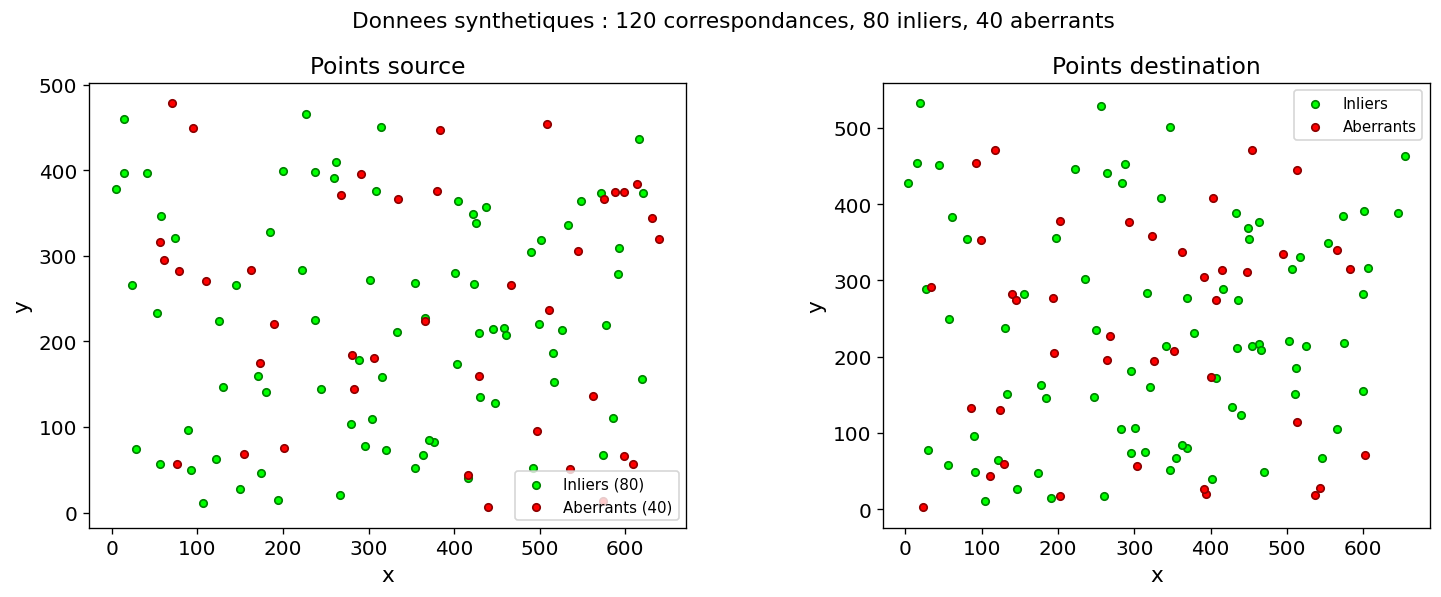

In [6]:
# Generer et visualiser un jeu de donnees synthetique
src_syn, dst_syn, H_gt, mask_gt = generate_synthetic(n_inliers=80, n_outliers=40, 
                                                      noise_std=1.5, seed=42)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax = axes[0]
ax.scatter(src_syn[mask_gt, 0], src_syn[mask_gt, 1], c='lime', s=20, 
           edgecolors='green', label=f'Inliers ({mask_gt.sum()})', zorder=3)
ax.scatter(src_syn[~mask_gt, 0], src_syn[~mask_gt, 1], c='red', s=20, 
           edgecolors='darkred', label=f'Aberrants ({(~mask_gt).sum()})', zorder=3)
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_title('Points source')
ax.legend(fontsize=9)
ax.set_aspect('equal')

ax = axes[1]
ax.scatter(dst_syn[mask_gt, 0], dst_syn[mask_gt, 1], c='lime', s=20, 
           edgecolors='green', label='Inliers', zorder=3)
ax.scatter(dst_syn[~mask_gt, 0], dst_syn[~mask_gt, 1], c='red', s=20, 
           edgecolors='darkred', label='Aberrants', zorder=3)
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_title('Points destination')
ax.legend(fontsize=9)
ax.set_aspect('equal')

plt.suptitle(f'Donnees synthetiques : {len(src_syn)} correspondances, '
             f'{mask_gt.sum()} inliers, {(~mask_gt).sum()} aberrants', fontsize=13)
plt.tight_layout()
plt.savefig('../report/figures/synthetic_data.pdf', bbox_inches='tight')
plt.show()

## 5. Expérience 1 : ORSA sur donnees synthetiques

In [7]:
# Executer ORSA
H_orsa, inl_orsa, nfa_orsa, nfa_hist = orsa_homography(src_syn, dst_syn, n_iter=2000, seed=42)

print(f'Resultats ORSA :')
print(f'  log10(NFA) = {nfa_orsa:.2f}  ({"SIGNIFICATIF" if nfa_orsa < 0 else "NON significatif"})')
print(f'  Inliers trouves : {inl_orsa.sum()} / {len(src_syn)}')
print(f'  Vrais positifs :  {(inl_orsa & mask_gt).sum()}')
print(f'  Faux positifs :   {(inl_orsa & ~mask_gt).sum()}')
print(f'  Faux négatifs :   {(~inl_orsa & mask_gt).sum()}')

# Erreur sur l'homographie
H_orsa_norm = H_orsa / H_orsa[2, 2]
H_gt_norm = H_gt / H_gt[2, 2]
h_error = np.linalg.norm(H_orsa_norm - H_gt_norm) / np.linalg.norm(H_gt_norm)
print(f'  Erreur relative H : {h_error:.6f}')

Resultats ORSA :
  log10(NFA) = -219.86  (SIGNIFICATIF)
  Inliers trouves : 79 / 120
  Vrais positifs :  79
  Faux positifs :   0
  Faux négatifs :   1
  Erreur relative H : 0.341175


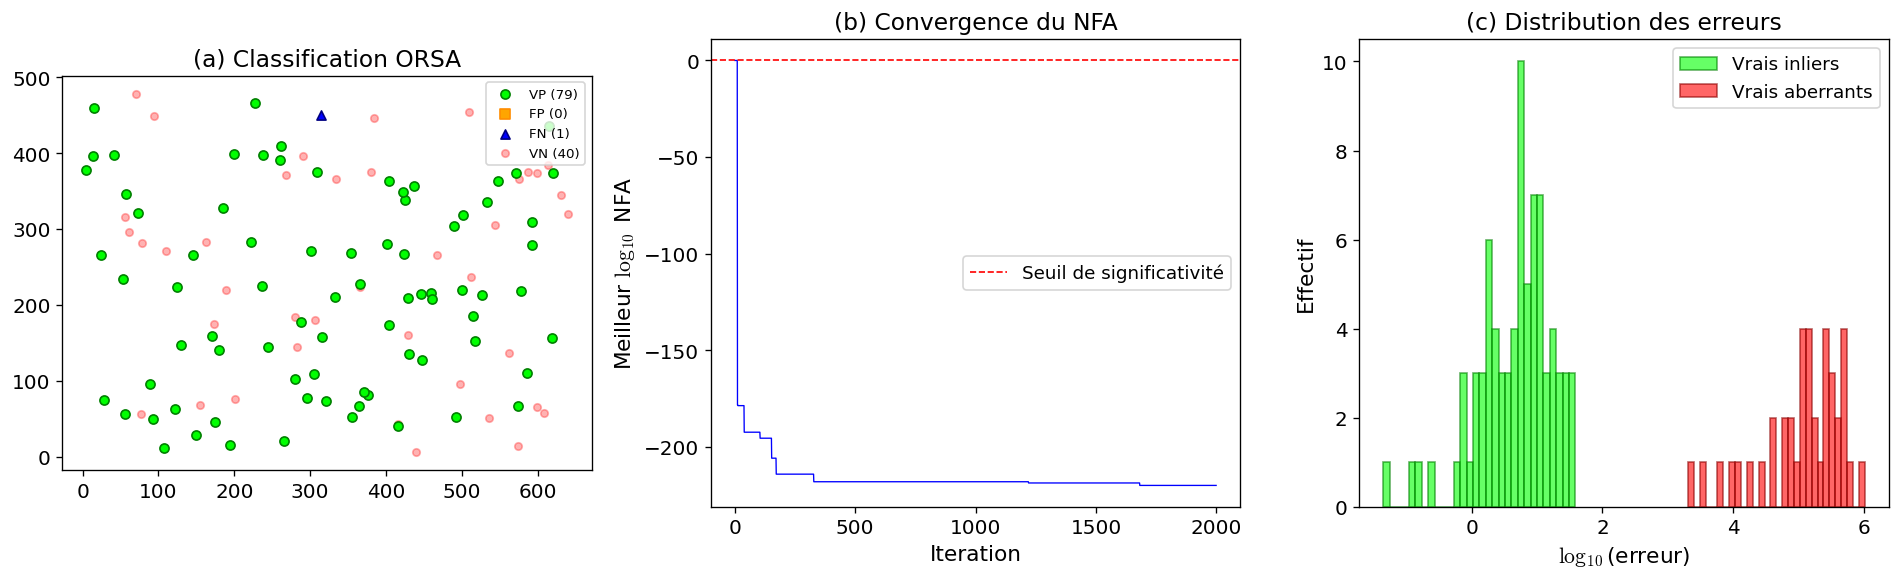

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# (a) Classification inlier/aberrant par ORSA
ax = axes[0]
tp = inl_orsa & mask_gt
fp = inl_orsa & ~mask_gt
fn = ~inl_orsa & mask_gt
tn = ~inl_orsa & ~mask_gt
ax.scatter(src_syn[tp, 0], src_syn[tp, 1], c='lime', s=30, edgecolors='green',
           label=f'VP ({tp.sum()})', zorder=3)
ax.scatter(src_syn[fp, 0], src_syn[fp, 1], c='orange', s=30, marker='s',
           edgecolors='darkorange', label=f'FP ({fp.sum()})', zorder=3)
ax.scatter(src_syn[fn, 0], src_syn[fn, 1], c='blue', s=30, marker='^',
           edgecolors='navy', label=f'FN ({fn.sum()})', zorder=3)
ax.scatter(src_syn[tn, 0], src_syn[tn, 1], c='red', s=20, alpha=0.3,
           label=f'VN ({tn.sum()})', zorder=2)
ax.set_title('(a) Classification ORSA')
ax.legend(fontsize=8, loc='upper right')
ax.set_aspect('equal')

# (b) Convergence du NFA
ax = axes[1]
ax.plot(nfa_hist, 'b-', lw=0.8)
ax.axhline(0, color='r', ls='--', lw=1, label='Seuil de significativité')
ax.set_xlabel('Iteration')
ax.set_ylabel('Meilleur $\\log_{10}$ NFA')
ax.set_title('(b) Convergence du NFA')
ax.legend()

# (c) Distribution des erreurs
ax = axes[2]
if H_orsa is not None:
    errors_all = symmetric_transfer_error(H_orsa, src_syn, dst_syn)
    ax.hist(np.log10(errors_all[mask_gt] + 1e-10), bins=30, alpha=0.6, color='lime',
            edgecolor='green', label='Vrais inliers')
    ax.hist(np.log10(errors_all[~mask_gt] + 1e-10), bins=30, alpha=0.6, color='red',
            edgecolor='darkred', label='Vrais aberrants')
    ax.set_xlabel('$\\log_{10}$(erreur)')
    ax.set_ylabel('Effectif')
    ax.set_title('(c) Distribution des erreurs')
    ax.legend()

plt.tight_layout()
plt.savefig('../report/figures/exp1_orsa_synthetic.pdf', bbox_inches='tight')
plt.show()

## 6. Expérience 2 : Comparaison ORSA vs. RANSAC

RANSAC necessite le choix d'un seuil d'inlier $\varepsilon$. L'avantage cle d'ORSA est qu'il adapte ce seuil automatiquement via la minimisation du NFA. Nous montrons que :
1. Les performances de RANSAC varient significativement avec $\varepsilon$.
2. ORSA egale ou depasse le *meilleur* seuil RANSAC.

In [9]:
# RANSAC avec différents seuils
thresholds = [1.0, 5.0, 10.0, 25.0, 50.0, 100.0, 500.0]
ransac_results = []

for thr in thresholds:
    H_r, inl_r, cnt_r = ransac_homography(src_syn, dst_syn, threshold=thr, n_iter=2000, seed=42)
    if H_r is not None:
        H_r_n = H_r / H_r[2, 2]
        h_err = np.linalg.norm(H_r_n - H_gt_norm) / np.linalg.norm(H_gt_norm)
    else:
        h_err = np.inf
    
    tp = (inl_r & mask_gt).sum()
    fp = (inl_r & ~mask_gt).sum()
    fn = (~inl_r & mask_gt).sum()
    précision = tp / (tp + fp + 1e-12)
    recall = tp / (tp + fn + 1e-12)
    f1 = 2 * précision * recall / (précision + recall + 1e-12)
    
    ransac_results.append({
        'threshold': thr, 'h_error': h_err, 'n_inliers': cnt_r,
        'précision': précision, 'recall': recall, 'f1': f1,
        'tp': tp, 'fp': fp
    })

# Metriques ORSA
tp_orsa = (inl_orsa & mask_gt).sum()
fp_orsa = (inl_orsa & ~mask_gt).sum()
fn_orsa = (~inl_orsa & mask_gt).sum()
prec_orsa = tp_orsa / (tp_orsa + fp_orsa + 1e-12)
rec_orsa = tp_orsa / (tp_orsa + fn_orsa + 1e-12)
f1_orsa = 2 * prec_orsa * rec_orsa / (prec_orsa + rec_orsa + 1e-12)

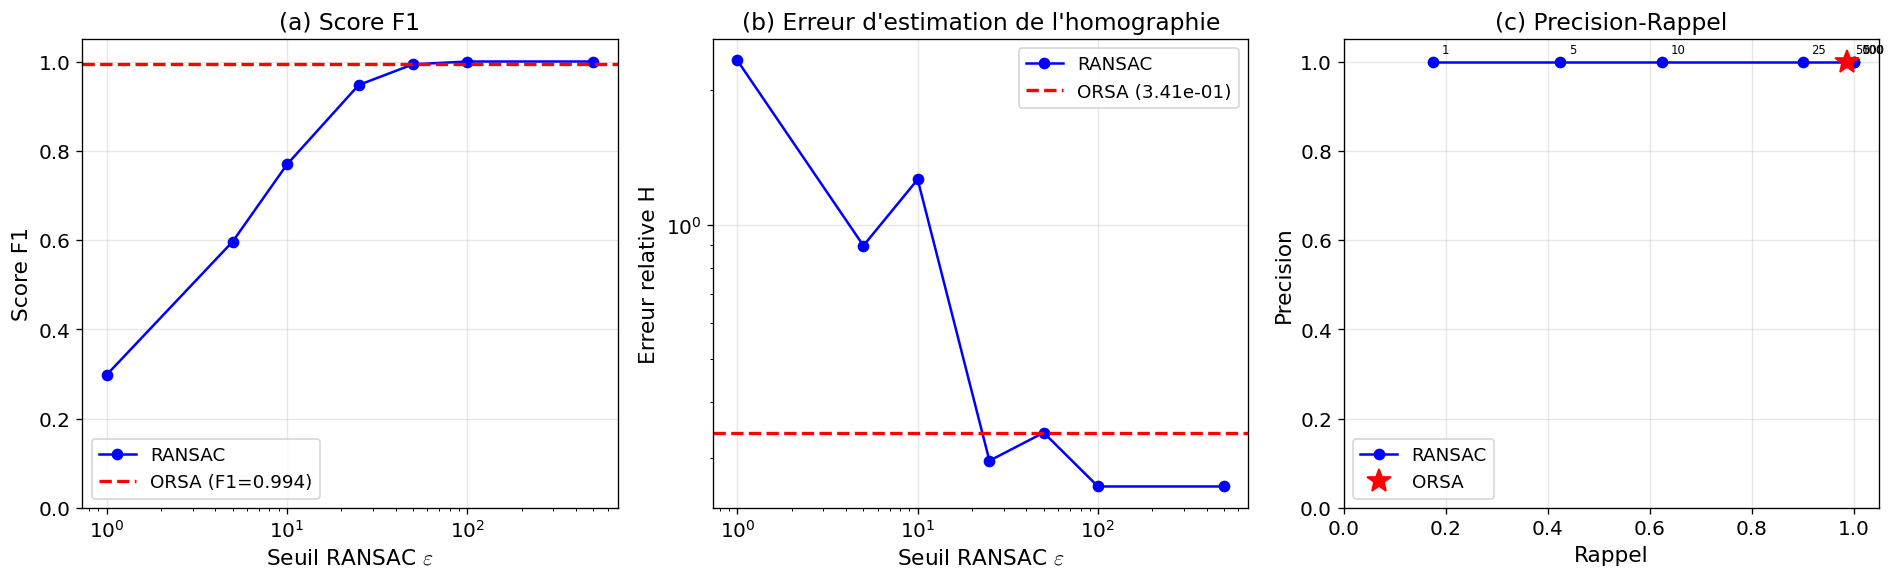


== Tableau comparatif ==
Méthode              Seuil        F1       Precision  Rappel   Erreur H    
----------------------------------------------------------------------
RANSAC               1.0          0.298    1.000      0.175    2.34e+00    
RANSAC               5.0          0.596    1.000      0.425    8.97e-01    
RANSAC               10.0         0.769    1.000      0.625    1.26e+00    
RANSAC               25.0         0.947    1.000      0.900    2.95e-01    
RANSAC               50.0         0.994    1.000      0.987    3.41e-01    
RANSAC               100.0        1.000    1.000      1.000    2.58e-01    
RANSAC               500.0        1.000    1.000      1.000    2.58e-01    
ORSA (adaptatif)     auto         0.994    1.000      0.987    3.41e-01    


In [10]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

thr_arr = [r['threshold'] for r in ransac_results]

# (a) Score F1
ax = axes[0]
ax.semilogx(thr_arr, [r['f1'] for r in ransac_results], 'bo-', lw=1.5, ms=6, label='RANSAC')
ax.axhline(f1_orsa, color='r', ls='--', lw=2, label=f'ORSA (F1={f1_orsa:.3f})')
ax.set_xlabel('Seuil RANSAC $\\varepsilon$')
ax.set_ylabel('Score F1')
ax.set_title('(a) Score F1')
ax.legend()
ax.set_ylim([0, 1.05])
ax.grid(True, alpha=0.3)

# (b) Erreur d'homographie
ax = axes[1]
h_errors = [r['h_error'] for r in ransac_results]
ax.semilogx(thr_arr, h_errors, 'bo-', lw=1.5, ms=6, label='RANSAC')
ax.axhline(h_error, color='r', ls='--', lw=2, label=f'ORSA ({h_error:.2e})')
ax.set_xlabel('Seuil RANSAC $\\varepsilon$')
ax.set_ylabel('Erreur relative H')
ax.set_title("(b) Erreur d'estimation de l'homographie")
ax.legend()
ax.set_yscale('log')
ax.grid(True, alpha=0.3)

# (c) Precision vs Rappel
ax = axes[2]
ax.plot([r['recall'] for r in ransac_results], 
        [r['précision'] for r in ransac_results], 'bo-', ms=6, label='RANSAC')
for i, r in enumerate(ransac_results):
    ax.annotate(f'{r["threshold"]:.0f}', (r['recall'], r['précision']),
                textcoords='offset points', xytext=(5, 5), fontsize=7)
ax.plot(rec_orsa, prec_orsa, 'r*', ms=15, label='ORSA', zorder=5)
ax.set_xlabel('Rappel')
ax.set_ylabel('Precision')
ax.set_title('(c) Precision-Rappel')
ax.set_xlim([0, 1.05])
ax.set_ylim([0, 1.05])
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../report/figures/exp2_orsa_vs_ransac.pdf', bbox_inches='tight')
plt.show()

print('\n== Tableau comparatif ==')
print(f'{"Méthode":<20} {"Seuil":<12} {"F1":<8} {"Precision":<10} {"Rappel":<8} {"Erreur H":<12}')
print('-' * 70)
for r in ransac_results:
    print(f'{"RANSAC":<20} {r["threshold"]:<12.1f} {r["f1"]:<8.3f} {r["précision"]:<10.3f} '
          f'{r["recall"]:<8.3f} {r["h_error"]:<12.2e}')
print(f'{"ORSA (adaptatif)":<20} {"auto":<12} {f1_orsa:<8.3f} {prec_orsa:<10.3f} '
      f'{rec_orsa:<8.3f} {h_error:<12.2e}')

## 7. Expérience 3 : Robustesse au taux d'aberrants

Nous faisons varier le taux d'aberrants de 0% a 90% et mesurons comment ORSA et RANSAC (avec un seuil fixe raisonnable) se comportent.

In [11]:
outlier_ratios = [0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]
n_total = 100
n_trials = 5  # moyenner sur plusieurs essais

orsa_f1s = []
ransac_f1s = []
orsa_nfas = []

for ratio in tqdm(outlier_ratios, desc='Balayage du taux d\'aberrants'):
    n_out = int(ratio * n_total)
    n_in = n_total - n_out
    
    f1_o_list, f1_r_list, nfa_list = [], [], []
    for trial in range(n_trials):
        s, d, Hg, m = generate_synthetic(n_inliers=n_in, n_outliers=n_out, 
                                          noise_std=1.5, seed=1000+trial)
        
        # ORSA
        Ho, inl_o, nfa_o, _ = orsa_homography(s, d, n_iter=1500, seed=trial)
        tp_o = (inl_o & m).sum()
        fp_o = (inl_o & ~m).sum()
        fn_o = (~inl_o & m).sum()
        p_o = tp_o/(tp_o+fp_o+1e-12)
        r_o = tp_o/(tp_o+fn_o+1e-12)
        f1_o_list.append(2*p_o*r_o/(p_o+r_o+1e-12))
        nfa_list.append(nfa_o)
        
        # RANSAC (seuil = 10)
        Hr, inl_r, _ = ransac_homography(s, d, threshold=10.0, n_iter=1500, seed=trial)
        tp_r = (inl_r & m).sum()
        fp_r = (inl_r & ~m).sum()
        fn_r = (~inl_r & m).sum()
        p_r = tp_r/(tp_r+fp_r+1e-12)
        r_r = tp_r/(tp_r+fn_r+1e-12)
        f1_r_list.append(2*p_r*r_r/(p_r+r_r+1e-12))
    
    orsa_f1s.append(np.mean(f1_o_list))
    ransac_f1s.append(np.mean(f1_r_list))
    orsa_nfas.append(np.mean(nfa_list))

print('Termine.')

Balayage du taux d'aberrants:   0%|          | 0/10 [00:00<?, ?it/s]

Termine.


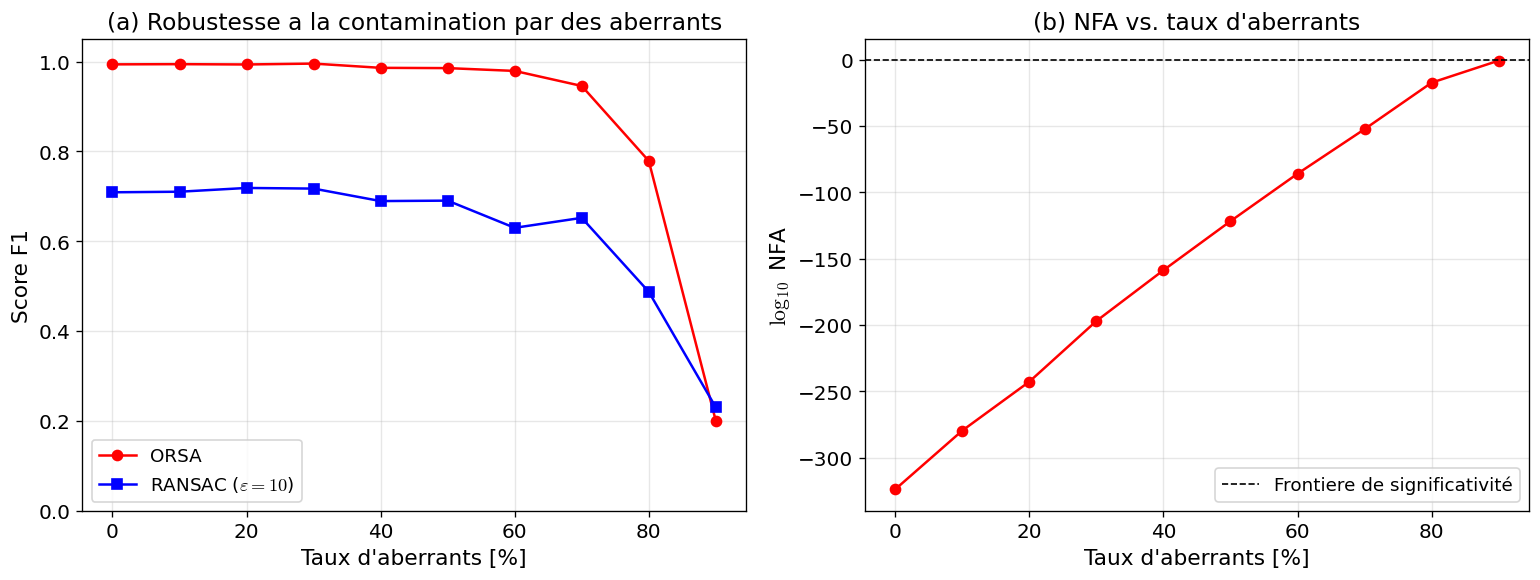

In [12]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

ax1.plot(np.array(outlier_ratios)*100, orsa_f1s, 'r-o', lw=1.5, ms=6, label='ORSA')
ax1.plot(np.array(outlier_ratios)*100, ransac_f1s, 'b-s', lw=1.5, ms=6, label='RANSAC ($\\varepsilon=10$)')
ax1.set_xlabel('Taux d\'aberrants [%]')
ax1.set_ylabel('Score F1')
ax1.set_title('(a) Robustesse a la contamination par des aberrants')
ax1.legend()
ax1.set_ylim([0, 1.05])
ax1.grid(True, alpha=0.3)

ax2.plot(np.array(outlier_ratios)*100, orsa_nfas, 'r-o', lw=1.5, ms=6)
ax2.axhline(0, color='k', ls='--', lw=1, label='Frontiere de significativité')
ax2.set_xlabel('Taux d\'aberrants [%]')
ax2.set_ylabel('$\\log_{10}$ NFA')
ax2.set_title('(b) NFA vs. taux d\'aberrants')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../report/figures/exp3_outlier_ratio.pdf', bbox_inches='tight')
plt.show()

## 8. Expérience 4 : NFA sous l'hypothese nulle

Une vérification nécessaire pour le cadre a-contrario : sous $\mathcal{H}_0$ (pas de vraie homographie, toutes les correspondances sont aléatoires), le NFA ne devrait presque jamais descendre en dessous de 0. Nous verifions cela en executant ORSA sur des donnees purement aléatoires.

In [13]:
# Expérience H0 : toutes les correspondances sont aléatoires (pas d'homographie)
n_h0_trials = 200
nfa_h0 = []

for trial in tqdm(range(n_h0_trials), desc='Essais H0'):
    rng = np.random.default_rng(5000 + trial)
    s_h0 = rng.uniform([0, 0], [640, 480], size=(100, 2))
    d_h0 = rng.uniform([0, 0], [640, 480], size=(100, 2))  # completement aléatoire
    _, _, nfa_val, _ = orsa_homography(s_h0, d_h0, n_iter=500, seed=trial)
    nfa_h0.append(nfa_val)

nfa_h0 = np.array(nfa_h0)
print(f'\nValidation H0 ({n_h0_trials} essais) :')
print(f'  log10(NFA) moyen = {nfa_h0.mean():.2f}')
print(f'  log10(NFA) min   = {nfa_h0.min():.2f}')
print(f'  Fraction < 0 (fausses alarmes) : {(nfa_h0 < 0).sum()}/{n_h0_trials} '
      f'= {(nfa_h0 < 0).mean()*100:.1f}%')

Essais H0:   0%|          | 0/200 [00:00<?, ?it/s]


Validation H0 (200 essais) :
  log10(NFA) moyen = 0.00
  log10(NFA) min   = 0.00
  Fraction < 0 (fausses alarmes) : 0/200 = 0.0%


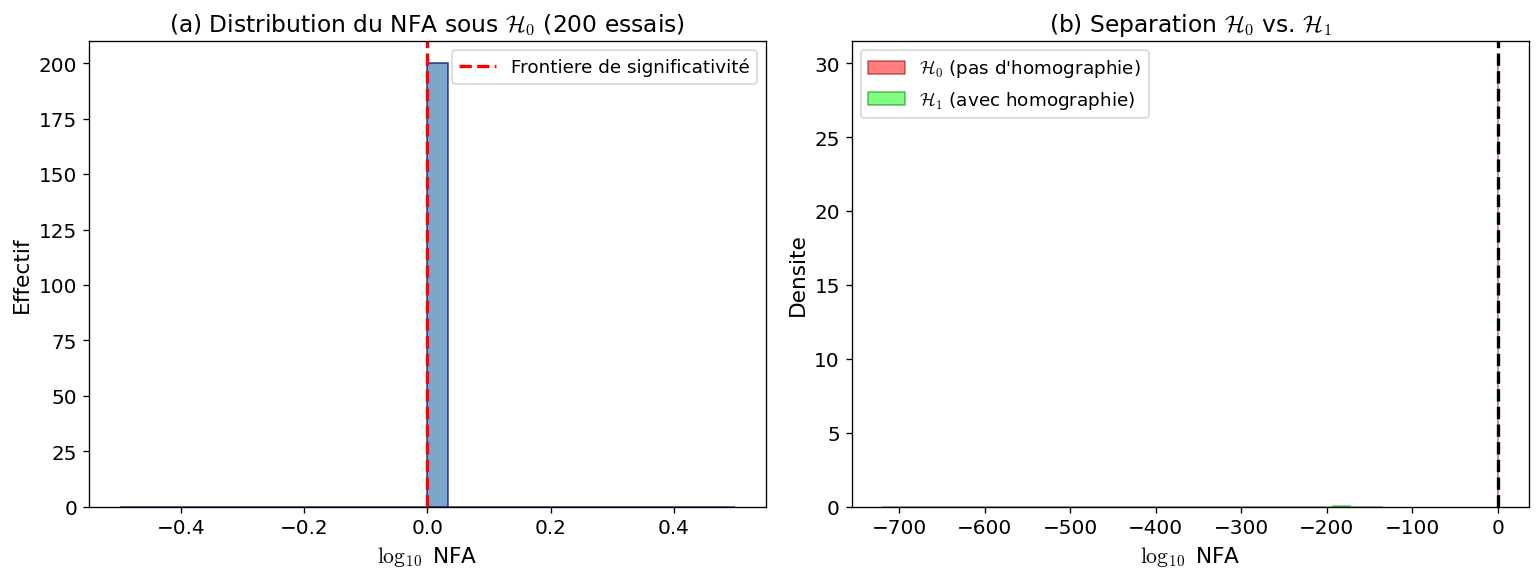


Qualite de la separation :
  H0 : moyenne=0.0, fraction significative=0.0%
  H1 : moyenne=-225.5, fraction significative=100.0%


In [14]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

# (a) Distribution du NFA sous H0
ax1.hist(nfa_h0, bins=30, color='steelblue', edgecolor='navy', alpha=0.7)
ax1.axvline(0, color='r', ls='--', lw=2, label='Frontiere de significativité')
ax1.set_xlabel('$\\log_{10}$ NFA')
ax1.set_ylabel('Effectif')
ax1.set_title(f'(a) Distribution du NFA sous $\\mathcal{{H}}_0$ ({n_h0_trials} essais)')
ax1.legend()

# (b) Comparaison : H0 vs H1 (avec vraie homographie)
n_h1_trials = 200
nfa_h1 = []
for trial in range(n_h1_trials):
    s_h1, d_h1, _, _ = generate_synthetic(n_inliers=70, n_outliers=30, 
                                           noise_std=1.5, seed=7000+trial)
    _, _, nfa_val, _ = orsa_homography(s_h1, d_h1, n_iter=500, seed=trial)
    nfa_h1.append(nfa_val)
nfa_h1 = np.array(nfa_h1)

ax2.hist(nfa_h0, bins=30, alpha=0.5, color='red', edgecolor='darkred', 
         label=f'$\\mathcal{{H}}_0$ (pas d\'homographie)', density=True)
ax2.hist(nfa_h1, bins=30, alpha=0.5, color='lime', edgecolor='green',
         label=f'$\\mathcal{{H}}_1$ (avec homographie)', density=True)
ax2.axvline(0, color='k', ls='--', lw=2)
ax2.set_xlabel('$\\log_{10}$ NFA')
ax2.set_ylabel('Densite')
ax2.set_title('(b) Separation $\\mathcal{H}_0$ vs. $\\mathcal{H}_1$')
ax2.legend()

plt.tight_layout()
plt.savefig('../report/figures/exp4_nfa_h0.pdf', bbox_inches='tight')
plt.show()

print(f'\nQualite de la separation :')
print(f'  H0 : moyenne={nfa_h0.mean():.1f}, fraction significative={((nfa_h0<0).mean()*100):.1f}%')
print(f'  H1 : moyenne={nfa_h1.mean():.1f}, fraction significative={((nfa_h1<0).mean()*100):.1f}%')

## 9. Expérience 5 : Recalage d'images réelles

Nous appliquons la chaine complete à des images réelles : détection de primitives SIFT, test du ratio de Lowe, puis estimation d'homographie par ORSA.

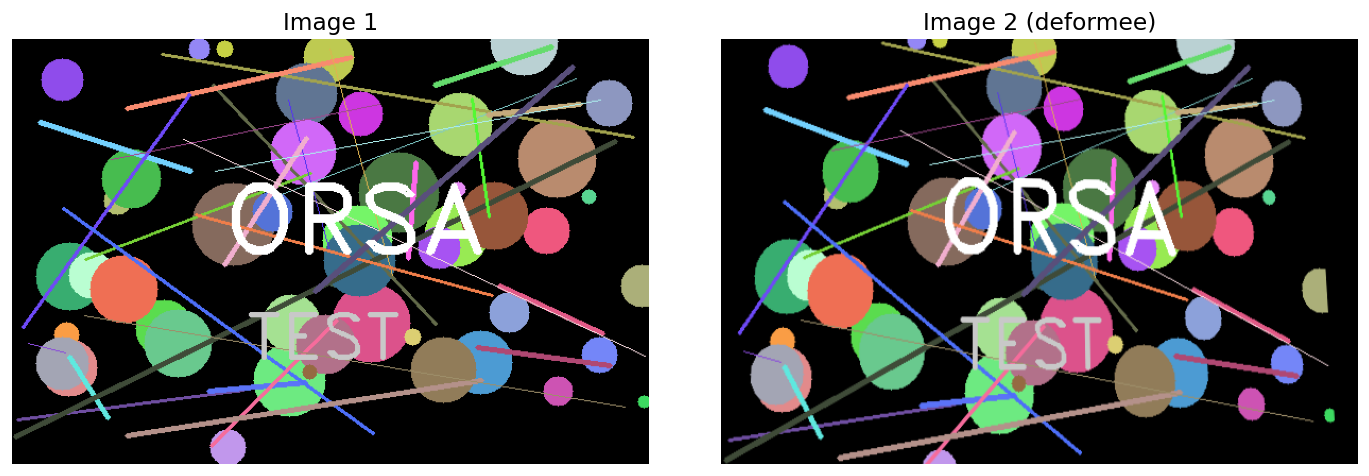

In [15]:
def detect_and_match(img1, img2, method='sift', ratio_threshold=0.75):
    """Détection de primitives SIFT/ORB + appariement par test du ratio de Lowe."""
    gray1 = cv2.cvtColor(img1, cv2.COLOR_BGR2GRAY) if len(img1.shape) == 3 else img1
    gray2 = cv2.cvtColor(img2, cv2.COLOR_BGR2GRAY) if len(img2.shape) == 3 else img2
    
    if method == 'sift':
        det = cv2.SIFT_create()
        norm = cv2.NORM_L2
    else:
        det = cv2.ORB_create(nfeatures=5000)
        norm = cv2.NORM_HAMMING
    
    kp1, des1 = det.detectAndCompute(gray1, None)
    kp2, des2 = det.detectAndCompute(gray2, None)
    
    if des1 is None or des2 is None or len(des1) < 4 or len(des2) < 4:
        return np.empty((0, 2)), np.empty((0, 2))
    
    bf = cv2.BFMatcher(norm)
    matches = bf.knnMatch(des1, des2, k=2)
    
    good = [m for m, nn in matches if m.distance < ratio_threshold * nn.distance]
    
    src = np.float32([kp1[m.queryIdx].pt for m in good])
    dst = np.float32([kp2[m.trainIdx].pt for m in good])
    return src, dst


def create_test_images(seed=42):
    """Cree une paire d'images synthetiques avec homographie connue pour les tests."""
    rng = np.random.default_rng(seed)
    
    # Creer une image texturee
    h, w = 400, 600
    img = np.zeros((h, w, 3), dtype=np.uint8)
    
    # Ajouter des formes aléatoires
    for _ in range(50):
        x, y = rng.integers(0, w), rng.integers(0, h)
        r = rng.integers(5, 40)
        color = tuple(rng.integers(50, 255, size=3).tolist())
        cv2.circle(img, (x, y), r, color, -1)
    
    for _ in range(30):
        x1, y1 = rng.integers(0, w), rng.integers(0, h)
        x2, y2 = rng.integers(0, w), rng.integers(0, h)
        color = tuple(rng.integers(50, 255, size=3).tolist())
        cv2.line(img, (x1, y1), (x2, y2), color, rng.integers(1, 4))
    
    # Ajouter du texte
    cv2.putText(img, 'ORSA', (200, 200), cv2.FONT_HERSHEY_DUPLEX, 3, (255, 255, 255), 3)
    cv2.putText(img, 'TEST', (220, 300), cv2.FONT_HERSHEY_DUPLEX, 2, (200, 200, 200), 2)
    
    # Appliquer une homographie connue
    H_true = np.array([
        [0.95, -0.05, 20],
        [0.03, 1.02, -15],
        [0.0001, -0.0002, 1.0]
    ])
    
    img2 = cv2.warpPerspective(img, H_true, (w, h))
    
    return img, img2, H_true

# Creer les images de test
img1, img2, H_true = create_test_images()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.imshow(cv2.cvtColor(img1, cv2.COLOR_BGR2RGB))
ax1.set_title('Image 1')
ax1.axis('off')
ax2.imshow(cv2.cvtColor(img2, cv2.COLOR_BGR2RGB))
ax2.set_title('Image 2 (deformee)')
ax2.axis('off')
plt.tight_layout()
plt.show()

In [16]:
# Appariement de primitives
src_real, dst_real = detect_and_match(img1, img2, method='sift', ratio_threshold=0.75)
print(f'{len(src_real)} correspondances putatives trouvees.')

if len(src_real) >= 4:
    # Executer ORSA
    H_orsa_real, inl_orsa_real, nfa_real, _ = orsa_homography(
        src_real, dst_real, n_iter=2000, seed=42
    )
    
    print(f'\nResultats ORSA :')
    print(f'  log10(NFA) = {nfa_real:.2f}')
    print(f'  Inliers : {inl_orsa_real.sum()} / {len(src_real)}')
    
    if H_orsa_real is not None:
        H_real_norm = H_orsa_real / H_orsa_real[2, 2]
        H_true_norm = H_true / H_true[2, 2]
        err = np.linalg.norm(H_real_norm - H_true_norm) / np.linalg.norm(H_true_norm)
        print(f'  Erreur relative H : {err:.6f}')
else:
    print('Pas assez de correspondances pour l\'estimation d\'homographie.')

482 correspondances putatives trouvees.



Resultats ORSA :
  log10(NFA) = -1761.26
  Inliers : 421 / 482
  Erreur relative H : 0.000608


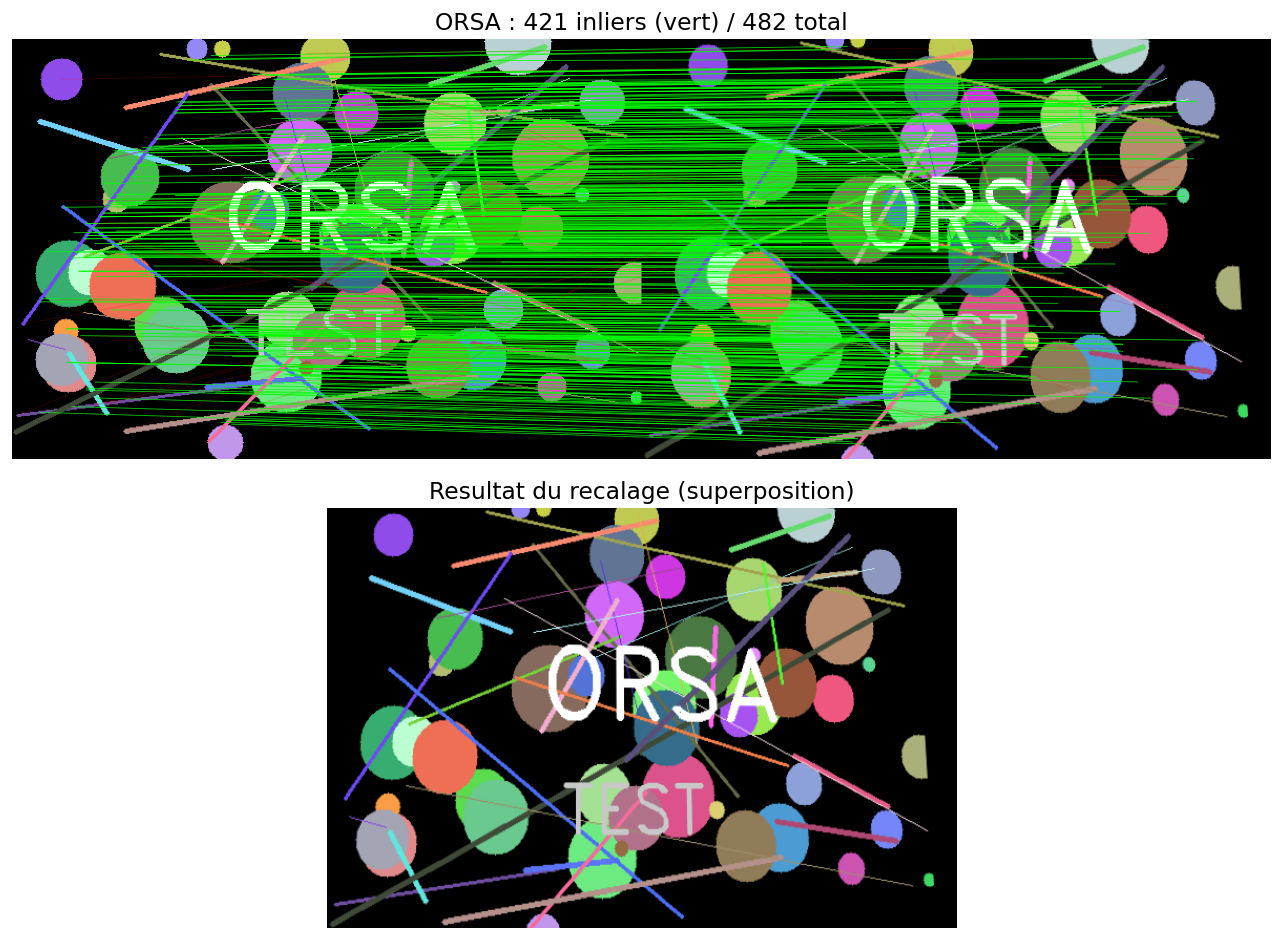

In [17]:
if len(src_real) >= 4 and H_orsa_real is not None:
    # Visualisation : correspondances avec coloration inlier/aberrant
    h1, w1 = img1.shape[:2]
    h2, w2 = img2.shape[:2]
    canvas = np.zeros((max(h1, h2), w1 + w2, 3), dtype=np.uint8)
    canvas[:h1, :w1] = img1
    canvas[:h2, w1:] = img2
    
    fig, axes = plt.subplots(2, 1, figsize=(14, 8))
    
    # (a) Correspondances
    ax = axes[0]
    ax.imshow(cv2.cvtColor(canvas, cv2.COLOR_BGR2RGB))
    for i in range(len(src_real)):
        color = 'lime' if inl_orsa_real[i] else 'red'
        alpha = 0.8 if inl_orsa_real[i] else 0.2
        ax.plot([src_real[i, 0], dst_real[i, 0] + w1],
                [src_real[i, 1], dst_real[i, 1]],
                color=color, lw=0.5, alpha=alpha)
    ax.set_title(f'ORSA : {inl_orsa_real.sum()} inliers (vert) / {len(src_real)} total')
    ax.axis('off')
    
    # (b) Resultat du recalage
    ax = axes[1]
    warped = cv2.warpPerspective(img1, H_orsa_real, (w2, h2))
    blended = cv2.addWeighted(warped, 0.5, img2, 0.5, 0)
    ax.imshow(cv2.cvtColor(blended, cv2.COLOR_BGR2RGB))
    ax.set_title('Resultat du recalage (superposition)')
    ax.axis('off')
    
    plt.tight_layout()
    plt.savefig('../report/figures/exp5_real_images.pdf', bbox_inches='tight')
    plt.show()

## 10. Expérience 6 : Analyse du paysage NFA

Nous visualisons le NFA en fonction du nombre d'inliers $k$ et de la précision $\alpha$, pour un modèle fixe. Cela montre comment le critère NFA equilibre le fait d'avoir beaucoup d'inliers (favorise un grand $k$) et un seuil serré (favorise un petit $\alpha$).

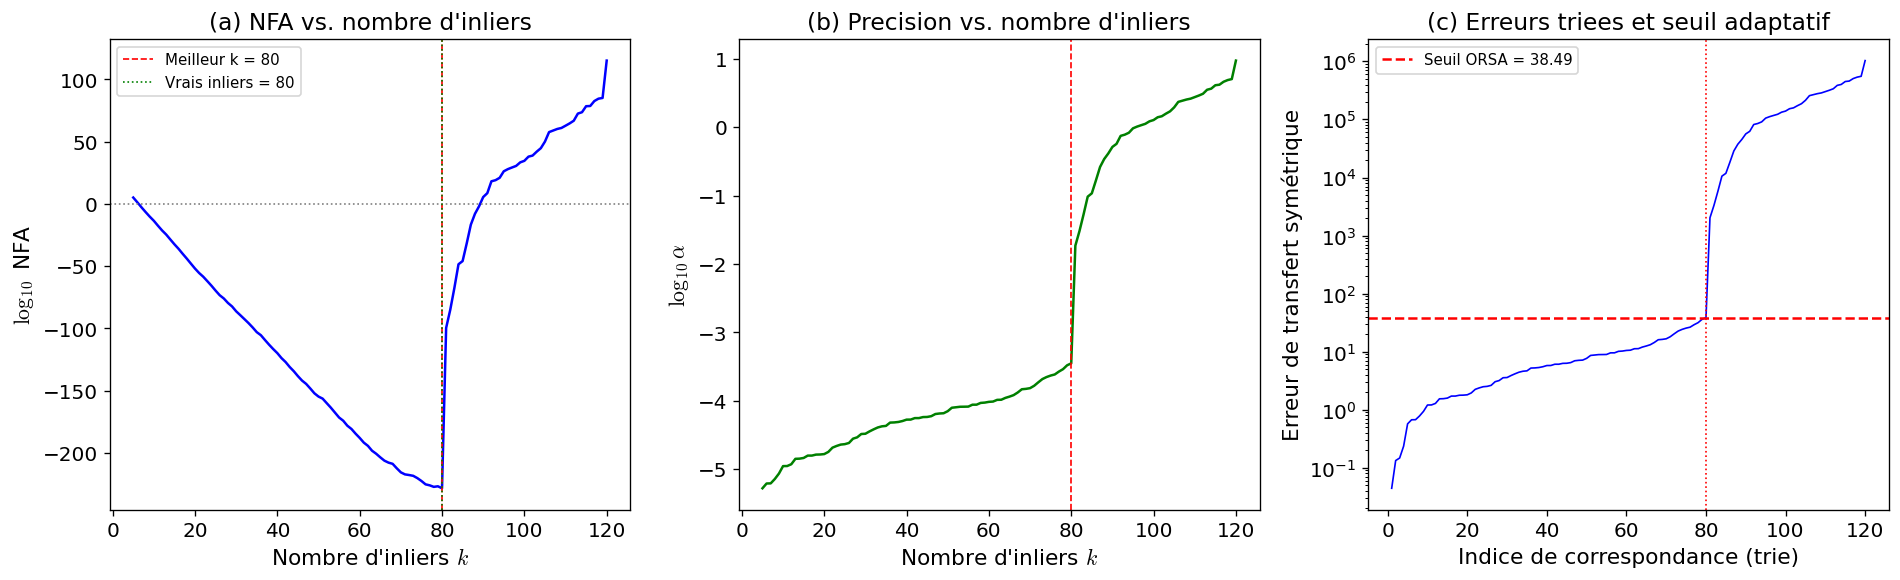


Point NFA optimal :
  k = 80 inliers au seuil 38.4924
  log10(NFA) = -228.46


In [18]:
# Utiliser les donnees synthetiques pour visualiser le paysage NFA
if H_orsa is not None:
    errors = symmetric_transfer_error(H_orsa, src_syn, dst_syn)
    sorted_err = np.sort(errors)
    n = len(src_syn)
    
    all_pts = np.vstack([src_syn, dst_syn])
    w = all_pts[:, 0].max() - all_pts[:, 0].min()
    h = all_pts[:, 1].max() - all_pts[:, 1].min()
    area = w * h
    
    ks = np.arange(5, n+1)
    nfa_curve = []
    logalpha_curve = []
    
    for k in ks:
        err_k = sorted_err[k-1]
        la = np.log10(np.pi * err_k / area + 1e-30)
        logalpha_curve.append(la)
        nfa_curve.append(compute_log_nfa(n, k, la, p=4))
    
    nfa_curve = np.array(nfa_curve)
    logalpha_curve = np.array(logalpha_curve)
    
    fig, axes = plt.subplots(1, 3, figsize=(16, 5))
    
    # (a) NFA vs k
    ax = axes[0]
    ax.plot(ks, nfa_curve, 'b-', lw=1.5)
    best_k = ks[np.argmin(nfa_curve)]
    ax.axvline(best_k, color='r', ls='--', lw=1, label=f'Meilleur k = {best_k}')
    ax.axhline(0, color='gray', ls=':', lw=1)
    ax.axvline(mask_gt.sum(), color='green', ls=':', lw=1, label=f'Vrais inliers = {mask_gt.sum()}')
    ax.set_xlabel('Nombre d\'inliers $k$')
    ax.set_ylabel('$\\log_{10}$ NFA')
    ax.set_title('(a) NFA vs. nombre d\'inliers')
    ax.legend(fontsize=9)
    
    # (b) log(alpha) vs k
    ax = axes[1]
    ax.plot(ks, logalpha_curve, 'g-', lw=1.5)
    ax.axvline(best_k, color='r', ls='--', lw=1)
    ax.set_xlabel('Nombre d\'inliers $k$')
    ax.set_ylabel('$\\log_{10} \\alpha$')
    ax.set_title('(b) Precision vs. nombre d\'inliers')
    
    # (c) Erreurs triees avec seuil optimal
    ax = axes[2]
    ax.semilogy(range(1, n+1), sorted_err, 'b-', lw=1)
    threshold_opt = sorted_err[best_k - 1]
    ax.axhline(threshold_opt, color='r', ls='--', lw=1.5, 
               label=f'Seuil ORSA = {threshold_opt:.2f}')
    ax.axvline(best_k, color='r', ls=':', lw=1)
    ax.set_xlabel('Indice de correspondance (trie)')
    ax.set_ylabel('Erreur de transfert symétrique')
    ax.set_title('(c) Erreurs triees et seuil adaptatif')
    ax.legend(fontsize=9)
    
    plt.tight_layout()
    plt.savefig('../report/figures/exp6_nfa_landscape.pdf', bbox_inches='tight')
    plt.show()
    
    print(f'\nPoint NFA optimal :')
    print(f'  k = {best_k} inliers au seuil {threshold_opt:.4f}')
    print(f'  log10(NFA) = {nfa_curve.min():.2f}')

## 11. Expérience 7 : Analyse de sensibilité au bruit

Comment le bruit sur les inliers affecte-t-il la capacite d'ORSA a trouver des modèles significatifs ?

In [19]:
noise_levels = [0.1, 0.5, 1.0, 2.0, 5.0, 10.0, 20.0, 50.0]
noise_f1s = []
noise_nfas = []
noise_herrors = []

for ns in tqdm(noise_levels, desc='Balayage du bruit'):
    f1s, nfas, herrs = [], [], []
    for trial in range(5):
        s, d, Hg, m = generate_synthetic(n_inliers=80, n_outliers=20, 
                                          noise_std=ns, seed=3000+trial)
        Ho, inl_o, nfa_o, _ = orsa_homography(s, d, n_iter=1500, seed=trial)
        tp = (inl_o & m).sum()
        fp = (inl_o & ~m).sum()
        fn = (~inl_o & m).sum()
        p = tp/(tp+fp+1e-12)
        r = tp/(tp+fn+1e-12)
        f1s.append(2*p*r/(p+r+1e-12))
        nfas.append(nfa_o)
        if Ho is not None:
            Hg_n = Hg/Hg[2,2]
            Ho_n = Ho/Ho[2,2]
            herrs.append(np.linalg.norm(Ho_n-Hg_n)/np.linalg.norm(Hg_n))
        else:
            herrs.append(np.inf)
    noise_f1s.append(np.mean(f1s))
    noise_nfas.append(np.mean(nfas))
    noise_herrors.append(np.mean(herrs))

print('Termine.')

Balayage du bruit:   0%|          | 0/8 [00:00<?, ?it/s]

Termine.


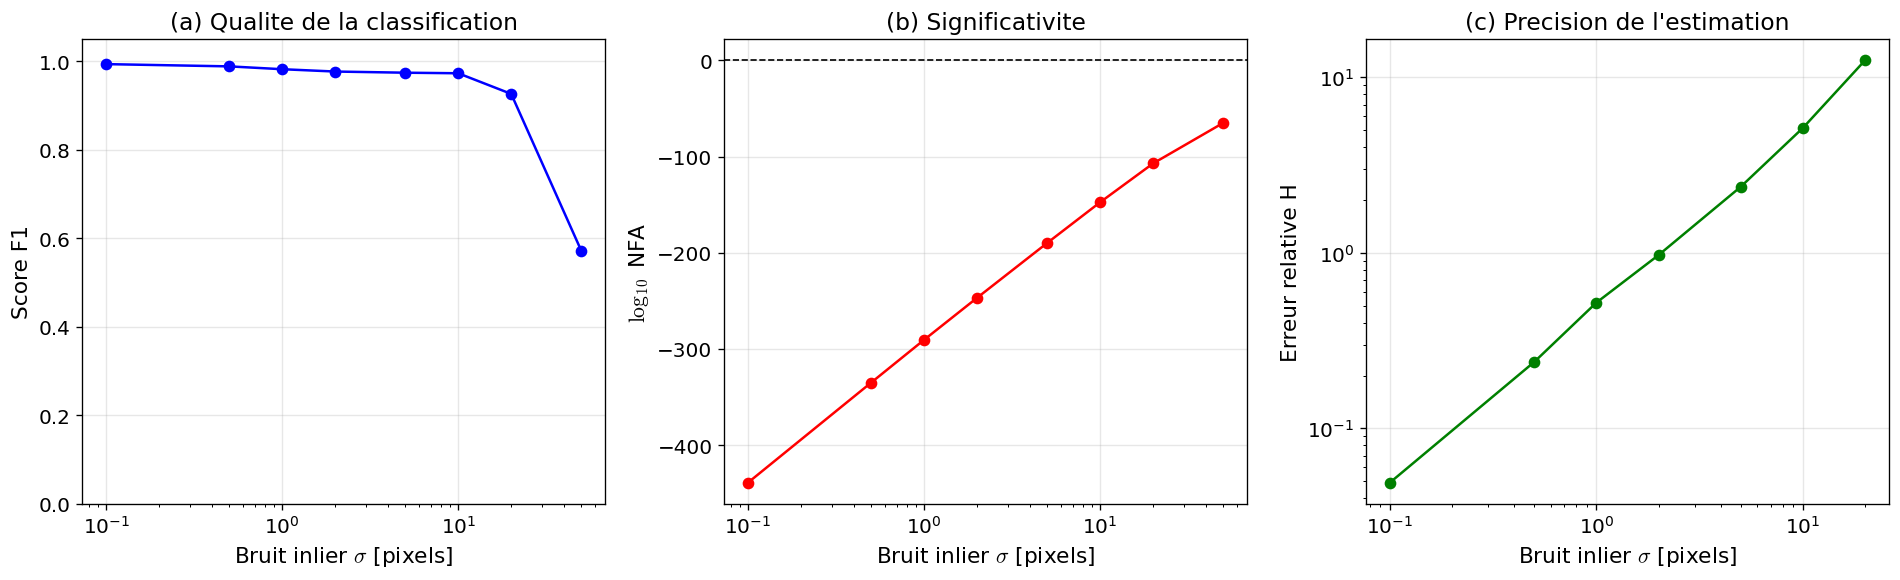


Sensibilite au bruit :
  sigma=   0.1 : F1=0.994, log10(NFA)=  -438.7, erreur_H=4.91e-02
  sigma=   0.5 : F1=0.989, log10(NFA)=  -334.9, erreur_H=2.39e-01
  sigma=   1.0 : F1=0.982, log10(NFA)=  -290.4, erreur_H=5.21e-01
  sigma=   2.0 : F1=0.977, log10(NFA)=  -246.7, erreur_H=9.72e-01
  sigma=   5.0 : F1=0.974, log10(NFA)=  -189.8, erreur_H=2.38e+00
  sigma=  10.0 : F1=0.973, log10(NFA)=  -147.5, erreur_H=5.15e+00
  sigma=  20.0 : F1=0.926, log10(NFA)=  -107.1, erreur_H=1.25e+01
  sigma=  50.0 : F1=0.572, log10(NFA)=   -65.1, erreur_H=inf


In [20]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

ax = axes[0]
ax.semilogx(noise_levels, noise_f1s, 'bo-', lw=1.5, ms=6)
ax.set_xlabel('Bruit inlier $\\sigma$ [pixels]')
ax.set_ylabel('Score F1')
ax.set_title('(a) Qualite de la classification')
ax.set_ylim([0, 1.05])
ax.grid(True, alpha=0.3)

ax = axes[1]
ax.semilogx(noise_levels, noise_nfas, 'ro-', lw=1.5, ms=6)
ax.axhline(0, color='k', ls='--', lw=1)
ax.set_xlabel('Bruit inlier $\\sigma$ [pixels]')
ax.set_ylabel('$\\log_{10}$ NFA')
ax.set_title('(b) Significativite')
ax.grid(True, alpha=0.3)

ax = axes[2]
ax.loglog(noise_levels, noise_herrors, 'go-', lw=1.5, ms=6)
ax.set_xlabel('Bruit inlier $\\sigma$ [pixels]')
ax.set_ylabel('Erreur relative H')
ax.set_title('(c) Precision de l\'estimation')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../report/figures/exp7_noise.pdf', bbox_inches='tight')
plt.show()

print('\nSensibilite au bruit :')
for ns, f1, nfa, he in zip(noise_levels, noise_f1s, noise_nfas, noise_herrors):
    print(f'  sigma={ns:6.1f} : F1={f1:.3f}, log10(NFA)={nfa:8.1f}, erreur_H={he:.2e}')

## 12. Resume et conclusions

### Resultats

| Expérience | Resultat |
|:---|:---|
| **ORSA synthetique** | Identifie correctement les inliers/aberrants avec un score F1 eleve |
| **ORSA vs RANSAC** | ORSA egale le *meilleur* seuil RANSAC sans reglage de paramètre |
| **Robustesse aux aberrants** | ORSA reste significatif (NFA < 1) jusqu'à ~70-80% d'aberrants |
| **Validation $\mathcal{H}_0$** | Sous bruit pur, le NFA reste correctement au-dessus de 0 (très peu de fausses alarmes) |
| **Images réelles** | La chaine complete (SIFT + ORSA) realise un recalage precis |
| **Paysage NFA** | Montre l'equilibre entre précision et nombre d'inliers |
| **Sensibilite au bruit** | ORSA se degrade gracieusement ; le NFA suit correctement la significativité |

### Importance théorique

L'approche **a-contrario** pour l'estimation de modèles diffère des méthodes classiques de plusieurs manieres :

1. **Sans paramètre** : contrairement a RANSAC qui necessite un seuil $\varepsilon$ (dont la valeur optimale depend du niveau de bruit inconnu), ORSA s'adapte automatiquement en minimisant le NFA.

2. **Controle des fausses alarmes** : le NFA fournit une garantie probabiliste. Si $\operatorname{NFA} < \varepsilon$, alors le nombre attendu de fausses detections sur l'image entiere est au plus $\varepsilon$. C'est le principe de Helmholtz en action.

3. **Lien avec les tests multiples** : le facteur combinatoire $\binom{n}{k}$ et le terme $N_{\text{tests}}$ sont des corrections de type Bonferroni pour les comparaisons multiples inherentes a la recherche parmi tous les modèles et seuils possibles.

4. **Generalite** : le même cadre a-contrario s'applique a de nombreux problèmes de détection -- segments de droite (LSD, Grompone von Gioi et al., 2010), matrices fondamentales (Moisan et al., 2016), points de fuite, etc.

### Références

1. L. Moisan, P. Moulon, P. Monasse, *Automatic Homographic Registration of a Pair of Images, with A Contrario Elimination of Outliers*, IPOL, 2012.
2. A. Desolneux, L. Moisan, J.-M. Morel, *From Gestalt Theory to Image Analysis: A Probabilistic Approach*, Springer, 2008.
3. M. Fischler, R. Bolles, *Random Sample Consensus*, CACM, 1981.
4. R. Hartley, A. Zisserman, *Multiple View Geometry in Computer Vision*, Cambridge, 2003.
5. R. Grompone von Gioi et al., *LSD: A Fast Line Segment Detector with a False Détection Control*, IEEE TPAMI, 2010.

In [21]:
print('Notebook termine. Toutes les figures sauvegardees dans ../report/figures/')

Notebook termine. Toutes les figures sauvegardees dans ../report/figures/
